In [5]:
import pandas as pd

df = pd.read_csv("../data/processed/cresci_2017_users_combined.csv")

print("Veri boyutu:", df.shape)
print("\nSütunlar:")
print(df.columns.tolist())

print("\nVeri tipleri:")
print(df.dtypes)

df.head()

Veri boyutu: (14368, 40)

Sütunlar:
['id', 'name', 'screen_name', 'statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'created_at', 'url', 'lang', 'time_zone', 'location', 'default_profile', 'default_profile_image', 'geo_enabled', 'profile_image_url', 'profile_banner_url', 'profile_use_background_image', 'profile_background_image_url_https', 'profile_text_color', 'profile_image_url_https', 'profile_sidebar_border_color', 'profile_background_tile', 'profile_sidebar_fill_color', 'profile_background_image_url', 'profile_background_color', 'profile_link_color', 'utc_offset', 'is_translator', 'follow_request_sent', 'protected', 'verified', 'notifications', 'description', 'contributors_enabled', 'following', 'updated', 'source_dataset', 'bot_label']

Veri tipleri:
id                                      int64
name                                   object
screen_name                            object
statuses_count                          int64
followers

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,url,...,follow_request_sent,protected,verified,notifications,description,contributors_enabled,following,updated,source_dataset,bot_label
0,80479674,YI YUAN,yi_twitts,29,19,255,1,0,Wed Oct 07 03:19:21 +0000 2009,http://www.jycondo.com,...,NaN,NaN,NaN,NaN,real estate sales,NaN,NaN,2013-06-12 18:38:35,fake_followers,1
1,82487179,Marcos Perez C,marcos_peca,1408,208,866,138,0,Wed Oct 14 23:40:17 +0000 2009,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-06-12 18:38:35,fake_followers,1
2,105830531,curti lorenzo,curtilorenzo,39,59,962,8,0,Sun Jan 17 16:46:52 +0000 2010,http://www.valcavargna.com/,...,NaN,NaN,NaN,NaN,le corna del capro scappato dal gregge s'infil...,NaN,NaN,2013-06-12 18:38:35,fake_followers,1
3,114488344,ruben dario toscano,gatito2710,59,7,49,4,0,Mon Feb 15 15:49:58 +0000 2010,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-06-12 18:38:35,fake_followers,1
4,123222267,Malek Khalaf,MalekKhalaf,987,60,521,61,1,Mon Mar 15 11:38:55 +0000 2010,http://www.facebook.com/Malek.AlBalawi,...,NaN,NaN,NaN,NaN,"MA student at JU, Interested in Juventus,Italy...",NaN,NaN,2013-06-11 17:39:44,fake_followers,1


In [6]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_ratio": (df.isnull().mean() * 100).round(2)
}).sort_values(by="missing_count", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_ratio
follow_request_sent,14368,100.00
following,14368,100.00
contributors_enabled,14368,100.00
notifications,14368,100.00
is_translator,14367,99.99
verified,14357,99.92
protected,14290,99.46
default_profile_image,14290,99.46
geo_enabled,10935,76.11
url,10759,74.88


In [7]:
cols_to_drop_high_missing = [
    "follow_request_sent",
    "following",
    "contributors_enabled",
    "notifications",
    "is_translator",
    "verified",
    "protected",
    "default_profile_image"
]

df_step1 = df.drop(columns=cols_to_drop_high_missing).copy()

print("Eski boyut:", df.shape)
print("Yeni boyut:", df_step1.shape)

remaining_missing = pd.DataFrame({
    "missing_count": df_step1.isnull().sum(),
    "missing_ratio": (df_step1.isnull().mean() * 100).round(2)
}).sort_values(by="missing_count", ascending=False)

remaining_missing[remaining_missing["missing_count"] > 0]

Eski boyut: (14368, 40)
Yeni boyut: (14368, 32)


,missing_count,missing_ratio
geo_enabled,10935,76.11
url,10759,74.88
default_profile,9857,68.60
profile_banner_url,9482,65.99
utc_offset,9018,62.76
time_zone,9018,62.76
profile_background_tile,8867,61.71
location,6684,46.52
description,5744,39.98
profile_use_background_image,1523,10.60


In [8]:
cols_to_drop_high_missing = [
    "follow_request_sent",
    "following",
    "contributors_enabled",
    "notifications",
    "is_translator",
    "verified",
    "protected",
    "default_profile_image"
]

df_step1 = df.drop(columns=cols_to_drop_high_missing).copy()

print("Eski boyut:", df.shape)
print("Yeni boyut:", df_step1.shape)

remaining_missing = pd.DataFrame({
    "missing_count": df_step1.isnull().sum(),
    "missing_ratio": (df_step1.isnull().mean() * 100).round(2)
}).sort_values(by="missing_count", ascending=False)

remaining_missing[remaining_missing["missing_count"] > 0]

Eski boyut: (14368, 40)
Yeni boyut: (14368, 32)


,missing_count,missing_ratio
geo_enabled,10935,76.11
url,10759,74.88
default_profile,9857,68.60
profile_banner_url,9482,65.99
utc_offset,9018,62.76
time_zone,9018,62.76
profile_background_tile,8867,61.71
location,6684,46.52
description,5744,39.98
profile_use_background_image,1523,10.60


In [9]:
bool_like_cols = [
    "geo_enabled",
    "default_profile",
    "profile_background_tile",
    "profile_use_background_image"
]

for col in bool_like_cols:
    print(f"\n{'='*50}")
    print(f"Sütun: {col}")
    print(df_step1[col].value_counts(dropna=False))


Sütun: geo_enabled
geo_enabled
NaN    10935
1.0     3433
Name: count, dtype: int64

Sütun: default_profile
default_profile
NaN    9857
1.0    4511
Name: count, dtype: int64

Sütun: profile_background_tile
profile_background_tile
NaN    8867
1.0    5501
Name: count, dtype: int64

Sütun: profile_use_background_image
profile_use_background_image
1.0    12845
NaN     1523
Name: count, dtype: int64


In [10]:
bool_like_cols = [
    "geo_enabled",
    "default_profile",
    "profile_background_tile",
    "profile_use_background_image"
]

df_step2 = df_step1.copy()

for col in bool_like_cols:
    df_step2[col] = df_step2[col].fillna(0).astype(int)

print("Dönüşüm sonrası kontrol:\n")

for col in bool_like_cols:
    print(f"{col}:")
    print(df_step2[col].value_counts(dropna=False))
    print("-" * 40)

Dönüşüm sonrası kontrol:

geo_enabled:
geo_enabled
0    10935
1     3433
Name: count, dtype: int64
----------------------------------------
default_profile:
default_profile
0    9857
1    4511
Name: count, dtype: int64
----------------------------------------
profile_background_tile:
profile_background_tile
0    8867
1    5501
Name: count, dtype: int64
----------------------------------------
profile_use_background_image:
profile_use_background_image
1    12845
0     1523
Name: count, dtype: int64
----------------------------------------


In [11]:
text_presence_cols = {
    "url": "has_url",
    "location": "has_location",
    "description": "has_description",
    "time_zone": "has_time_zone",
    "profile_banner_url": "has_profile_banner"
}

df_step3 = df_step2.copy()

for original_col, new_col in text_presence_cols.items():
    df_step3[new_col] = (
        df_step3[original_col]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .astype(int)
    )

print("Yeni eklenen sütunlar:")
print(list(text_presence_cols.values()))

print("\nKontrol:")
for new_col in text_presence_cols.values():
    print(f"{new_col}:")
    print(df_step3[new_col].value_counts())
    print("-" * 40)

Yeni eklenen sütunlar:
['has_url', 'has_location', 'has_description', 'has_time_zone', 'has_profile_banner']

Kontrol:
has_url:
has_url
0    10759
1     3609
Name: count, dtype: int64
----------------------------------------
has_location:
has_location
1    7683
0    6685
Name: count, dtype: int64
----------------------------------------
has_description:
has_description
1    8624
0    5744
Name: count, dtype: int64
----------------------------------------
has_time_zone:
has_time_zone
0    9018
1    5350
Name: count, dtype: int64
----------------------------------------
has_profile_banner:
has_profile_banner
0    9482
1    4886
Name: count, dtype: int64
----------------------------------------


In [12]:
df_step4 = df_step3.copy()

# Tarih sütunlarını datetime formatına çeviriyoruz
df_step4["created_at_dt"] = pd.to_datetime(
    df_step4["created_at"],
    errors="coerce",
    utc=True
)

df_step4["updated_dt"] = pd.to_datetime(
    df_step4["updated"],
    errors="coerce",
    utc=True
)

# Hesabın snapshot anındaki yaşını gün cinsinden hesaplıyoruz
df_step4["account_age_days"] = (
    (df_step4["updated_dt"] - df_step4["created_at_dt"])
    .dt.total_seconds() / (24 * 60 * 60)
)

print("created_at_dt boş değer sayısı:", df_step4["created_at_dt"].isnull().sum())
print("updated_dt boş değer sayısı:", df_step4["updated_dt"].isnull().sum())
print("account_age_days boş değer sayısı:", df_step4["account_age_days"].isnull().sum())

print("\naccount_age_days özeti:")
print(df_step4["account_age_days"].describe())

C:\Users\emira\AppData\Local\Temp\ipykernel_4752\2261129127.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_step4["created_at_dt"] = pd.to_datetime(


created_at_dt boş değer sayısı: 1000
updated_dt boş değer sayısı: 0
account_age_days boş değer sayısı: 1000

account_age_days özeti:
count    13368.000000
mean      1097.039004
std        747.236686
min         43.243461
25%        634.698108
50%        754.650272
75%       1519.414253
max       3340.588634
Name: account_age_days, dtype: float64


In [13]:
invalid_created_at = df_step4[df_step4["created_at_dt"].isnull()][["created_at", "source_dataset", "bot_label"]]

print("Parse edilemeyen created_at sayısı:", invalid_created_at.shape[0])
print("\nKaynak veri seti dağılımı:")
print(invalid_created_at["source_dataset"].value_counts())

print("\nİlk 10 problemli created_at değeri:")
print(invalid_created_at["created_at"].head(10).to_string(index=False))

Parse edilemeyen created_at sayısı: 1000

Kaynak veri seti dağılımı:
source_dataset
traditional_spambots_1    1000
Name: count, dtype: int64

İlk 10 problemli created_at değeri:
1183552203000L
1185440851000L
1192725360000L
1196614406000L
1209536534000L
1211155018000L
1212017203000L
1216718943000L
1223578831000L
1223956217000L


In [14]:
df_step5 = df_step4.copy()

# created_at sütununu önce stringe çeviriyoruz
created_at_clean = df_step5["created_at"].astype(str).str.strip()

# Sonu L ile biten değerleri tespit ediyoruz
mask_long_timestamp = created_at_clean.str.endswith("L", na=False)

# Bu değerlerde sondaki L harfini kaldırıyoruz
created_at_clean.loc[mask_long_timestamp] = (
    created_at_clean.loc[mask_long_timestamp]
    .str.replace("L", "", regex=False)
)

# Önce normal tarih formatını parse etmeye çalışıyoruz
df_step5["created_at_dt_fixed"] = pd.to_datetime(
    created_at_clean,
    errors="coerce",
    utc=True
)

# Hâlâ boş kalan ve sadece rakamlardan oluşan değerleri milisaniye timestamp olarak parse ediyoruz
mask_still_null = df_step5["created_at_dt_fixed"].isnull()
mask_numeric = created_at_clean.str.fullmatch(r"\d+")

final_mask = mask_still_null & mask_numeric

df_step5.loc[final_mask, "created_at_dt_fixed"] = pd.to_datetime(
    created_at_clean.loc[final_mask],
    unit="ms",
    errors="coerce",
    utc=True
)

# Hesap yaşını yeniden hesaplıyoruz
df_step5["account_age_days_fixed"] = (
    (df_step5["updated_dt"] - df_step5["created_at_dt_fixed"])
    .dt.total_seconds() / (24 * 60 * 60)
)

print("Düzeltilmiş created_at boş değer sayısı:", df_step5["created_at_dt_fixed"].isnull().sum())
print("Düzeltilmiş account_age_days boş değer sayısı:", df_step5["account_age_days_fixed"].isnull().sum())

print("\naccount_age_days_fixed özeti:")
print(df_step5["account_age_days_fixed"].describe())

C:\Users\emira\AppData\Local\Temp\ipykernel_4752\3434855782.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_step5["created_at_dt_fixed"] = pd.to_datetime(


Düzeltilmiş created_at boş değer sayısı: 0
Düzeltilmiş account_age_days boş değer sayısı: 0

account_age_days_fixed özeti:
count    14368.000000
mean      1185.428274
std        790.346680
min         43.243461
25%        733.291377
50%        779.108733
75%       1763.827917
max       3340.588634
Name: account_age_days_fixed, dtype: float64


C:\Users\emira\AppData\Local\Temp\ipykernel_4752\3434855782.py:28: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_step5.loc[final_mask, "created_at_dt_fixed"] = pd.to_datetime(


In [15]:
baseline_features = [
    "statuses_count",
    "followers_count",
    "friends_count",
    "favourites_count",
    "listed_count",
    "geo_enabled",
    "default_profile",
    "profile_background_tile",
    "profile_use_background_image",
    "has_url",
    "has_location",
    "has_description",
    "has_time_zone",
    "has_profile_banner",
    "account_age_days_fixed"
]

model_df_v1 = df_step5[baseline_features + ["bot_label"]].copy()

print("Model veri boyutu:", model_df_v1.shape)

print("\nEksik değer kontrolü:")
print(model_df_v1.isnull().sum())

print("\nİlk 5 satır:")
display(model_df_v1.head())

Model veri boyutu: (14368, 16)

Eksik değer kontrolü:
statuses_count                  0
followers_count                 0
friends_count                   0
favourites_count                0
listed_count                    0
geo_enabled                     0
default_profile                 0
profile_background_tile         0
profile_use_background_image    0
has_url                         0
has_location                    0
has_description                 0
has_time_zone                   0
has_profile_banner              0
account_age_days_fixed          0
bot_label                       0
dtype: int64

İlk 5 satır:


,statuses_count,followers_count,friends_count,favourites_count,listed_count,geo_enabled,default_profile,profile_background_tile,profile_use_background_image,has_url,has_location,has_description,has_time_zone,has_profile_banner,account_age_days_fixed,bot_label
0,29,19,255,1,0,1,0,1,1,1,1,1,1,0,1344.638356,1
1,1408,208,866,138,0,1,0,0,1,0,0,0,1,1,1336.790486,1
2,39,59,962,8,0,0,0,0,1,1,1,1,1,0,1242.077581,1
3,59,7,49,4,0,0,1,0,1,0,1,0,1,0,1213.117095,1
4,987,60,521,61,1,1,0,0,0,1,1,1,1,1,1184.250567,1


In [16]:
from sklearn.model_selection import train_test_split

X = model_df_v1.drop(columns="bot_label")
y = model_df_v1["bot_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train boyutu:", X_train.shape)
print("X_test boyutu:", X_test.shape)
print("y_train boyutu:", y_train.shape)
print("y_test boyutu:", y_test.shape)

print("\nTrain sınıf dağılımı:")
print(y_train.value_counts(normalize=True))

print("\nTest sınıf dağılımı:")
print(y_test.value_counts(normalize=True))

X_train boyutu: (11494, 15)
X_test boyutu: (2874, 15)
y_train boyutu: (11494,)
y_test boyutu: (2874,)

Train sınıf dağılımı:
bot_label
1    0.758222
0    0.241778
Name: proportion, dtype: float64

Test sınıf dağılımı:
bot_label
1    0.758177
0    0.241823
Name: proportion, dtype: float64


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Pipeline:
# 1) Sayısal değişkenleri ölçekler
# 2) Logistic Regression modelini eğitir
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

# Modeli eğit
logreg_pipeline.fit(X_train, y_train)

# Tahminler
y_pred = logreg_pipeline.predict(X_test)
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

# Metrikler
print("Logistic Regression Sonuçları")
print("-" * 40)
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Sonuçları
----------------------------------------
Accuracy : 0.961
Precision: 0.9721
Recall   : 0.9766
F1 Score : 0.9744
ROC AUC  : 0.9763

Confusion Matrix:
[[ 634   61]
 [  51 2128]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       695
           1       0.97      0.98      0.97      2179

    accuracy                           0.96      2874
   macro avg       0.95      0.94      0.95      2874
weighted avg       0.96      0.96      0.96      2874



In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Sonuçları")
print("-" * 40)
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Sonuçları
----------------------------------------
Accuracy : 0.9889
Precision: 0.994
Recall   : 0.9913
F1 Score : 0.9926
ROC AUC  : 0.9981

Confusion Matrix:
[[ 682   13]
 [  19 2160]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       695
           1       0.99      0.99      0.99      2179

    accuracy                           0.99      2874
   macro avg       0.98      0.99      0.98      2874
weighted avg       0.99      0.99      0.99      2874



In [19]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "ROC AUC": round(roc_auc_score(y_test, y_proba), 4),
    },
    {
        "Model": "Random Forest",
        "Accuracy": round(accuracy_score(y_test, y_pred_rf), 4),
        "Precision": round(precision_score(y_test, y_pred_rf), 4),
        "Recall": round(recall_score(y_test, y_pred_rf), 4),
        "F1 Score": round(f1_score(y_test, y_pred_rf), 4),
        "ROC AUC": round(roc_auc_score(y_test, y_proba_rf), 4),
    }
])

comparison_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.9889,0.9940,0.9913,0.9926,0.9981
0,Logistic Regression,0.9610,0.9721,0.9766,0.9744,0.9763


In [20]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Sonuçları")
print("-" * 40)
print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba_xgb), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Sonuçları
----------------------------------------
Accuracy : 0.9885
Precision: 0.994
Recall   : 0.9908
F1 Score : 0.9924
ROC AUC  : 0.9981

Confusion Matrix:
[[ 682   13]
 [  20 2159]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       695
           1       0.99      0.99      0.99      2179

    accuracy                           0.99      2874
   macro avg       0.98      0.99      0.98      2874
weighted avg       0.99      0.99      0.99      2874



In [21]:
import sys
print(sys.executable)

c:\Users\emira\Desktop\twitter-bot-avcisi\venv\Scripts\python.exe


In [22]:
from sklearn.model_selection import train_test_split

X = model_df_v1.drop(columns="bot_label")
y = model_df_v1["bot_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "ROC AUC": round(roc_auc_score(y_test, y_proba), 4),
    },
    {
        "Model": "Random Forest",
        "Accuracy": round(accuracy_score(y_test, y_pred_rf), 4),
        "Precision": round(precision_score(y_test, y_pred_rf), 4),
        "Recall": round(recall_score(y_test, y_pred_rf), 4),
        "F1 Score": round(f1_score(y_test, y_pred_rf), 4),
        "ROC AUC": round(roc_auc_score(y_test, y_proba_rf), 4),
    },
    {
        "Model": "XGBoost",
        "Accuracy": round(accuracy_score(y_test, y_pred_xgb), 4),
        "Precision": round(precision_score(y_test, y_pred_xgb), 4),
        "Recall": round(recall_score(y_test, y_pred_xgb), 4),
        "F1 Score": round(f1_score(y_test, y_pred_xgb), 4),
        "ROC AUC": round(roc_auc_score(y_test, y_proba_xgb), 4),
    }
])

comparison_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.9889,0.9940,0.9913,0.9926,0.9981
2,XGBoost,0.9885,0.9940,0.9908,0.9924,0.9981
0,Logistic Regression,0.9610,0.9721,0.9766,0.9744,0.9763


In [24]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_df

,feature,importance
3,favourites_count,0.377951
0,statuses_count,0.217601
13,has_profile_banner,0.128036
1,followers_count,0.085800
14,account_age_days_fixed,0.051108
5,geo_enabled,0.040869
2,friends_count,0.035190
4,listed_count,0.017263
12,has_time_zone,0.015285
11,has_description,0.009140


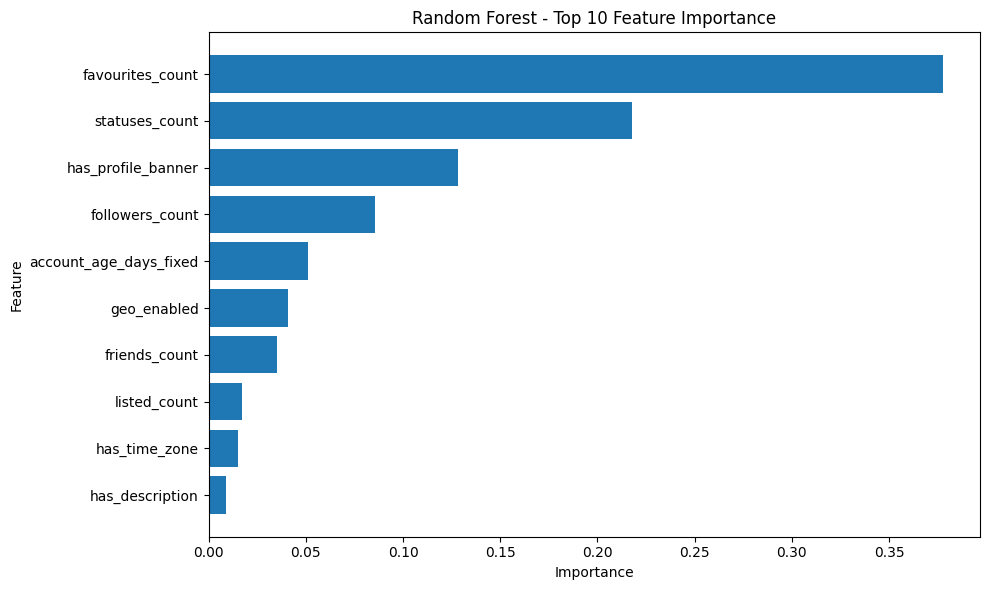

In [25]:
import matplotlib.pyplot as plt

top_n = 10
top_features = feature_importance_df.head(top_n).sort_values(by="importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Top 10 Feature Importance")
plt.tight_layout()
plt.show()

In [26]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "random_forest_bot_detector.joblib"
features_path = models_dir / "random_forest_feature_list.joblib"

joblib.dump(rf_model, model_path)
joblib.dump(baseline_features, features_path)

print("Model kaydedildi:", model_path)
print("Feature list kaydedildi:", features_path)

Model kaydedildi: ..\models\random_forest_bot_detector.joblib
Feature list kaydedildi: ..\models\random_forest_feature_list.joblib


In [27]:
import joblib
import pandas as pd
from pathlib import Path

# Kaydedilen dosyaları yükle
model_path = Path("../models/random_forest_bot_detector.joblib")
features_path = Path("../models/random_forest_feature_list.joblib")

loaded_model = joblib.load(model_path)
loaded_features = joblib.load(features_path)

# Test verisinden 1 örnek al
sample_input = X_test.iloc[[0]][loaded_features]

# Tahmin yap
sample_pred = loaded_model.predict(sample_input)[0]
sample_proba = loaded_model.predict_proba(sample_input)[0][1]

print("Tahmin edilen sınıf:", sample_pred)
print("Bot olasılığı:", round(sample_proba, 4))

print("\nKullanılan örnek:")
display(sample_input)

Tahmin edilen sınıf: 1
Bot olasılığı: 0.9998

Kullanılan örnek:


,statuses_count,followers_count,friends_count,favourites_count,listed_count,geo_enabled,default_profile,profile_background_tile,profile_use_background_image,has_url,has_location,has_description,has_time_zone,has_profile_banner,account_age_days_fixed
7345,34,1,0,0,0,0,0,0,1,0,1,1,1,0,1518.397049
